# Lung and Colon Cancer Classification using CNN

### Deep Learning Project

In this project I am training a CNN to classify histopathology images from the LC25000 dataset.

### What this project does

- classify the images into 5 classes
- train a CNN model
- check how well the model performs
- make a confusion matrix
- use Grad-CAM to see what parts of an image the model is focusing on

### Reference

I used the following GitHub project as a reference while making my version:

**AlexandruClitan/cancer-classification-cnn**  
https://github.com/AlexandruClitan/cancer-classification-cnn

Dataset: LC25000 by Borkowski et al.  
https://arxiv.org/abs/1912.12142

 Note: This is only a college/learning project. It should not be used for medical diagnosis.


In [1]:
# 1. Install dependencies
!pip -q install tensorflow scikit-learn seaborn opencv-python pillow kagglehub


In [2]:
# Imports

import os
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)

print("TensorFlow:", tf.__version__)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 12

CLASS_NAMES = [
    "colon_aca",
    "colon_n",
    "lung_aca",
    "lung_n",
    "lung_scc",
]

LABEL_TO_ID = {name: i for i, name in enumerate(CLASS_NAMES)}
ID_TO_LABEL = {i: name for name, i in LABEL_TO_ID.items()}


TensorFlow: 2.20.0


## 3. Getting the dataset

I am using the LC25000 dataset for this project. It is downloaded using Kagglehub and used for training and testing the CNN model.


In [3]:
# Download the dataset

import kagglehub

KAGGLE_DATASET = "andrewmvd/lung-and-colon-cancer-histopathological-images"

try:
    downloaded_path = kagglehub.dataset_download(KAGGLE_DATASET)
    print("Dataset downloaded to:", downloaded_path)
except Exception as exc:
    downloaded_path = None
    print("Automatic download failed.")
    print("Reason:", exc)
    print("You can manually download/extract the dataset and set DATASET_ROOT below.")


Using Colab cache for faster access to the 'lung-and-colon-cancer-histopathological-images' dataset.
Dataset downloaded to: /kaggle/input/lung-and-colon-cancer-histopathological-images


In [4]:
# Dataset location

# If automatic download worked, this usually points at the downloaded directory.
# If not, replace it with your manually extracted folder.

DATASET_ROOT = downloaded_path or "/content/LC25000"

print("DATASET_ROOT =", DATASET_ROOT)


DATASET_ROOT = /kaggle/input/lung-and-colon-cancer-histopathological-images


In [5]:
# Find the images

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}

ALIASES = {
    "colon_aca": ["colon_aca"],
    "colon_n": ["colon_n", "colon_benign"],
    "lung_aca": ["lung_aca"],
    "lung_n": ["lung_n", "lung_benign"],
    "lung_scc": ["lung_scc"],
}

def find_class_dir(root, aliases):
    root = Path(root)
    aliases = {a.lower() for a in aliases}

    for path in root.rglob("*"):
        if path.is_dir() and path.name.lower() in aliases:
            return path

    return None

rows = []

for class_name in CLASS_NAMES:
    class_dir = find_class_dir(
        DATASET_ROOT,
        ALIASES[class_name],
    )

    if class_dir is None:
        print("Missing:", class_name)
        continue

    files = [
        path
        for path in class_dir.rglob("*")
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    ]

    print(f"{class_name}: {len(files)} images")

    for path in files:
        rows.append({
            "path": str(path),
            "label": class_name,
        })

df = pd.DataFrame(rows)

if df.empty:
    raise RuntimeError(
        "No images were found. Check DATASET_ROOT and the class-folder names."
    )

print("\nTotal images:", len(df))
display(
    df["label"]
    .value_counts()
    .rename_axis("class")
    .reset_index(name="images")
)


colon_aca: 5000 images
colon_n: 5000 images
lung_aca: 5000 images
lung_n: 5000 images
lung_scc: 5000 images

Total images: 25000


,class,images
0,colon_aca,5000
1,colon_n,5000
2,lung_aca,5000
3,lung_n,5000
4,lung_scc,5000


## 5. Choosing how much data to use
To keep the training time manageable, 1000 images are used from each class. This provides a balanced subset of the dataset for training and evaluation.


In [21]:
MAX_PER_CLASS = 1000   # use None for all available images

if MAX_PER_CLASS is not None:
   df = (
    df.groupby("label", group_keys=False)
      .sample(n=MAX_PER_CLASS, random_state=SEED)
      .reset_index(drop=True)
)

print("Images used:", len(df))
display(
    df["label"]
    .value_counts()
    .rename_axis("class")
    .reset_index(name="images")
)


Images used: 5000


,class,images
0,colon_aca,1000
1,colon_n,1000
2,lung_aca,1000
3,lung_n,1000
4,lung_scc,1000


In [7]:
# Split the data

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED,
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED,
)

print(f"Train:      {len(train_df)}")
print(f"Validation: {len(val_df)}")
print(f"Test:       {len(test_df)}")


Train:      3500
Validation: 750
Test:       750


In [20]:
# Prepare the images

AUTOTUNE = tf.data.AUTOTUNE

def load_image(path, label):
    image_bytes = tf.io.read_file(path)
    image = tf.image.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False,
    )
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def make_dataset(frame, shuffle=False):
    paths = frame["path"].to_numpy()
    labels = frame["label"].map(LABEL_TO_ID).to_numpy()

    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=AUTOTUNE,
    )

    if shuffle:
        dataset = dataset.shuffle(
            min(len(frame), 2000),
            seed=SEED,
            reshuffle_each_iteration=True,
        )

    return dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)

print("Input pipeline ready.")


Input pipeline ready.


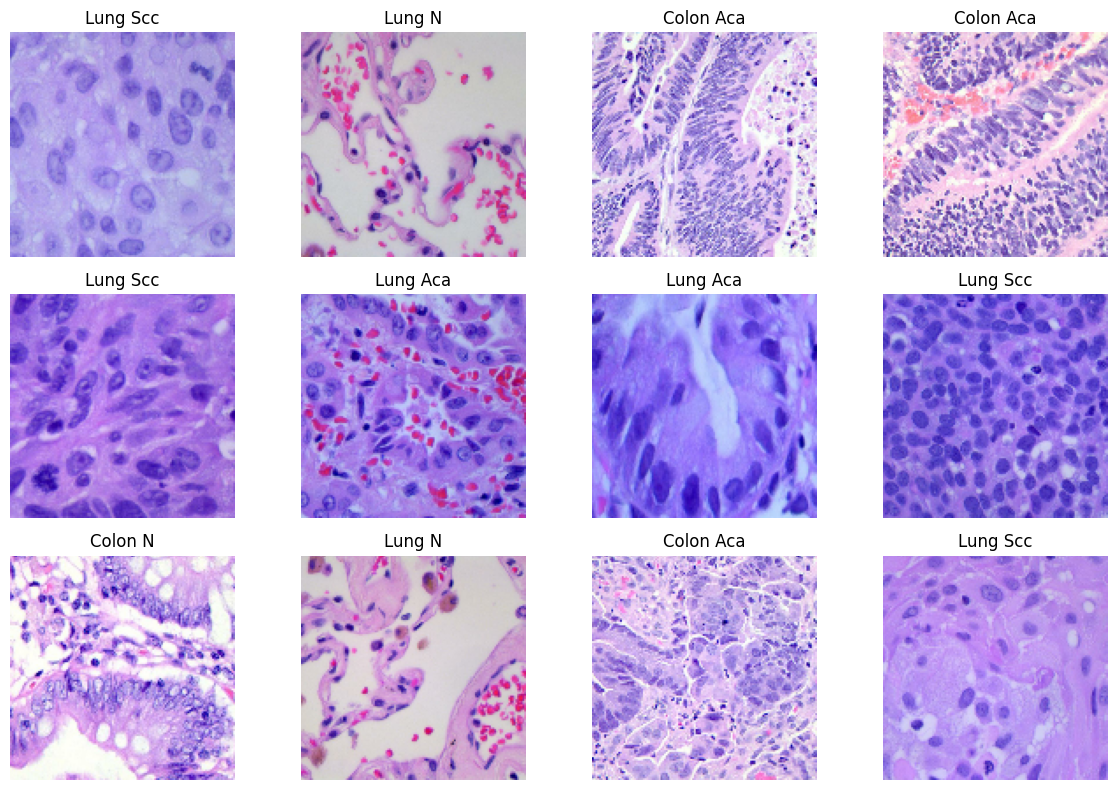

In [9]:
# Look at some images

images, labels = next(iter(train_ds))

plt.figure(figsize=(12, 8))

for i in range(min(12, len(images))):
    ax = plt.subplot(3, 4, i + 1)

    plt.imshow(images[i])
    plt.title(
        CLASS_NAMES[int(labels[i])]
        .replace("_", " ")
        .title()
    )
    plt.axis("off")

plt.tight_layout()
plt.show()


## 9. Making the CNN

A CNN model is used for image classification with convolution, pooling, dropout, and fully connected layers. The final convolutional layer is also used for Grad-CAM visualization

In [10]:
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip(
            "horizontal"
        ),
        tf.keras.layers.RandomRotation(
            0.08
        ),
        tf.keras.layers.RandomZoom(
            0.10
        ),
    ],
    name="data_augmentation",
)

model = tf.keras.Sequential(
    [
        tf.keras.layers.Input(
            shape=(*IMG_SIZE, 3)
        ),

        data_augmentation,

        tf.keras.layers.Conv2D(
            32, 3,
            padding="same",
            activation="relu",
            name="conv1",
        ),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(
            64, 3,
            padding="same",
            activation="relu",
            name="conv2",
        ),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(
            128, 3,
            padding="same",
            activation="relu",
            name="conv3",
        ),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(
            256, 3,
            padding="same",
            activation="relu",
            name="gradcam_conv",
        ),
        tf.keras.layers.BatchNormalization(),

        tf.keras.layers.GlobalAveragePooling2D(),

        tf.keras.layers.Dropout(0.35),

        tf.keras.layers.Dense(
            128,
            activation="relu",
        ),

        tf.keras.layers.Dropout(0.25),

        tf.keras.layers.Dense(
            len(CLASS_NAMES),
            activation="softmax",
            name="classifier",
        ),
    ],
    name="lung_colon_cancer_cnn",
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()


Model: "lung_colon_cancer_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gradcam_conv (Conv2D)           │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,877 (1.62 MB)

 Trainable params: 422,917 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [11]:
# Train the model

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "/content/best_lung_colon_cancer_cnn.keras",
        monitor="val_accuracy",
        save_best_only=True,
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)


Epoch 1/12
110/110 ━━━━━━━━━━━━━━━━━━━━ 29s 132ms/step - accuracy: 0.8020 - loss: 0.4856 - val_accuracy: 0.3933 - val_loss: 4.0722 - learning_rate: 0.0010
Epoch 2/12
110/110 ━━━━━━━━━━━━━━━━━━━━ 14s 85ms/step - accuracy: 0.8729 - loss: 0.3382 - val_accuracy: 0.2013 - val_loss: 5.1538 - learning_rate: 0.0010
Epoch 3/12
110/110 ━━━━━━━━━━━━━━━━━━━━ 13s 79ms/step - accuracy: 0.8874 - loss: 0.2853 - val_accuracy: 0.4293 - val_loss: 2.3016 - learning_rate: 0.0010
Epoch 4/12
110/110 ━━━━━━━━━━━━━━━━━━━━ 14s 88ms/step - accuracy: 0.9151 - loss: 0.2295 - val_accuracy: 0.4000 - val_loss: 5.1314 - learning_rate: 0.0010
Epoch 5/12
110/110 ━━━━━━━━━━━━━━━━━━━━ 15s 100ms/step - accuracy: 0.9137 - loss: 0.2254 - val_accuracy: 0.6080 - val_loss: 1.8585 - learning_rate: 0.0010
Epoch 6/12
110/110 ━━━━━━━━━━━━━━━━━━━━ 14s 87ms/step - accuracy: 0.9197 - loss: 0.2090 - val_accuracy: 0.5720 - val_loss: 2.0424 - learning_rate: 0.0010
Epoch 7/12
110/110 ━━━━━━━━━━━━━━━━━━━━ 14s 84ms/step - accuracy: 0.9283 -

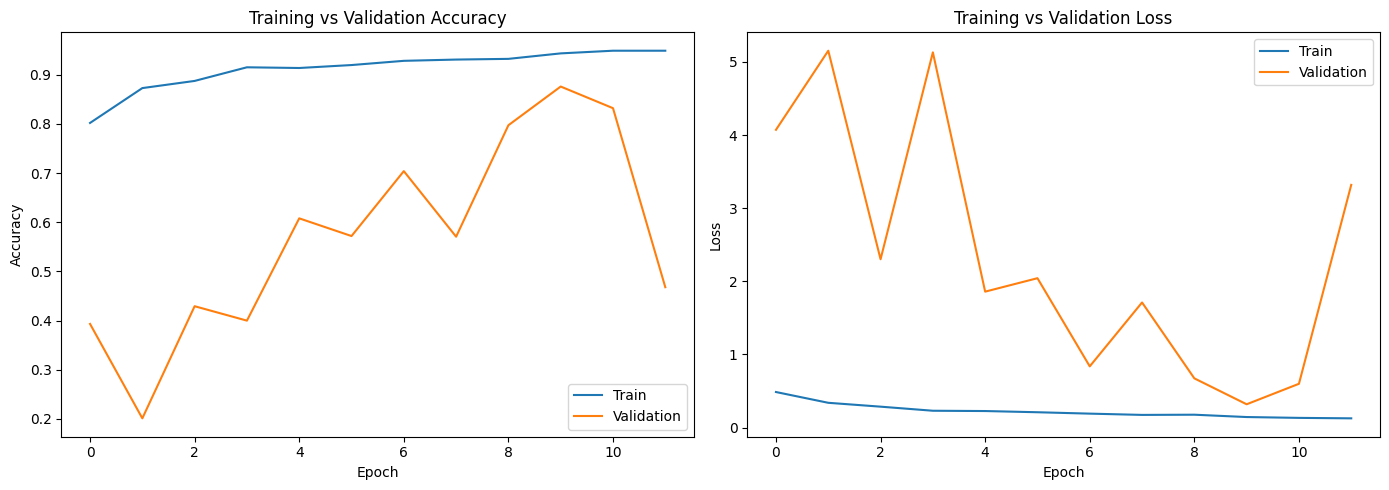

In [12]:
# Training graphs

history_df = pd.DataFrame(history.history)

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 5),
)

axes[0].plot(
    history_df["accuracy"],
    label="Train",
)
axes[0].plot(
    history_df["val_accuracy"],
    label="Validation",
)
axes[0].set_title("Training vs Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(
    history_df["loss"],
    label="Train",
)
axes[1].plot(
    history_df["val_loss"],
    label="Validation",
)
axes[1].set_title("Training vs Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()


In [13]:
# Test the model

test_loss, test_accuracy = model.evaluate(
    test_ds,
    verbose=1,
)

print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")


24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 149ms/step - accuracy: 0.8533 - loss: 0.3414
Test loss:     0.3414
Test accuracy: 0.8533


,precision,recall,f1-score,support
Colon Aca,0.969697,0.853333,0.907801,150.000000
Colon N,0.874251,0.973333,0.921136,150.000000
Lung Aca,0.688525,0.840000,0.756757,150.000000
Lung N,0.852273,1.000000,0.920245,150.000000
Lung Scc,0.978261,0.600000,0.743802,150.000000
accuracy,0.853333,0.853333,0.853333,0.853333
macro avg,0.872601,0.853333,0.849948,750.000000
weighted avg,0.872601,0.853333,0.849948,750.000000


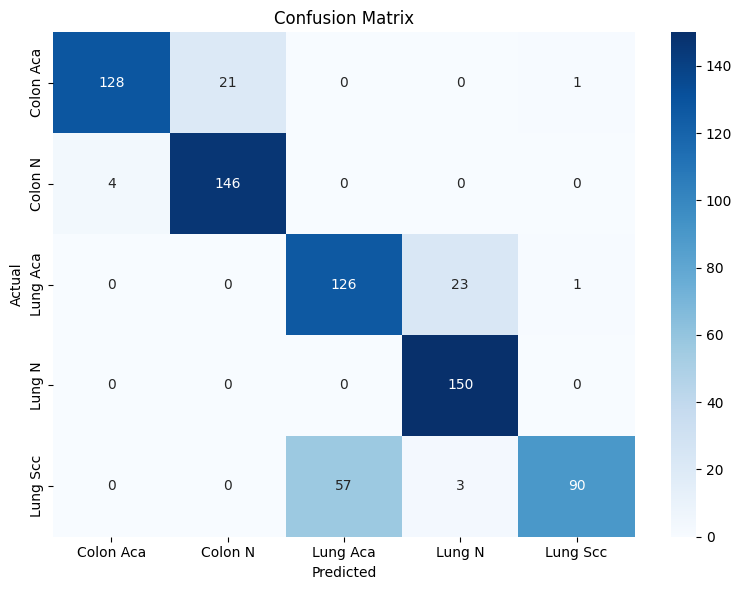

In [14]:
# More evaluation

y_true = []
y_pred = []

for batch_images, batch_labels in test_ds:
    probabilities = model.predict(
        batch_images,
        verbose=0,
    )

    predictions = np.argmax(
        probabilities,
        axis=1,
    )

    y_true.extend(
        batch_labels.numpy().tolist()
    )
    y_pred.extend(
        predictions.tolist()
    )

display(
    pd.DataFrame(
        classification_report(
            y_true,
            y_pred,
            target_names=[
                name.replace("_", " ").title()
                for name in CLASS_NAMES
            ],
            output_dict=True,
            zero_division=0,
        )
    ).T
)

cm = confusion_matrix(
    y_true,
    y_pred,
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        name.replace("_", " ").title()
        for name in CLASS_NAMES
    ],
    yticklabels=[
        name.replace("_", " ").title()
        for name in CLASS_NAMES
    ],
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


In [15]:
# Save the results

precision, recall, f1, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0,
)

metrics = {
    "test_accuracy": float(test_accuracy),
    "weighted_precision": float(precision),
    "weighted_recall": float(recall),
    "weighted_f1": float(f1),
}

print(metrics)

os.makedirs("/content/results", exist_ok=True)

pd.DataFrame([metrics]).to_csv(
    "/content/results/metrics.csv",
    index=False,
)

model.save(
    "/content/results/lung_colon_cancer_cnn.keras"
)

print("Saved metrics and model.")


{'test_accuracy': 0.8533333539962769, 'weighted_precision': 0.8726013307409675, 'weighted_recall': 0.8533333333333334, 'weighted_f1': 0.8499481747099478}
Saved metrics and model.


## 15. Grad-CAM

Grad-CAM gives a heatmap showing which parts of an image affected the prediction. It is useful for seeing what the model is looking at, but it does not prove that the highlighted area is medically important.


In [16]:
# Grad-CAM code

import cv2

def make_gradcam_heatmap_fixed(
    image_batch,
    model,
    last_conv_layer_name,
    pred_index=None,
):
    grad_model = tf.keras.models.Model(
        model.inputs,
        [
            model.get_layer(
                last_conv_layer_name
            ).output,
            model.output,
        ],
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(
            image_batch
        )

        if pred_index is None:
            pred_index = tf.argmax(
                predictions[0]
            )

        class_score = predictions[:, pred_index]

    gradients = tape.gradient(
        class_score,
        conv_outputs,
    )

    pooled_gradients = tf.reduce_mean(
        gradients,
        axis=(0, 1, 2),
    )

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_gradients[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(
        heatmap,
        0,
    )

    heatmap /= (
        tf.reduce_max(heatmap)
        + tf.keras.backend.epsilon()
    )

    return heatmap.numpy()


def overlay_gradcam(
    original_rgb,
    heatmap,
    alpha=0.40,
):
    heatmap_uint8 = np.uint8(
        np.clip(heatmap, 0, 1) * 255
    )

    heatmap_color = cv2.applyColorMap(
        heatmap_uint8,
        cv2.COLORMAP_JET,
    )

    heatmap_color = cv2.cvtColor(
        heatmap_color,
        cv2.COLOR_BGR2RGB,
    )

    heatmap_color = cv2.resize(
        heatmap_color,
        (
            original_rgb.shape[1],
            original_rgb.shape[0],
        ),
    )

    original_rgb = np.uint8(
        np.clip(
            original_rgb,
            0,
            255,
        )
    )

    return cv2.addWeighted(
        original_rgb,
        1 - alpha,
        heatmap_color,
        alpha,
        0,
    )


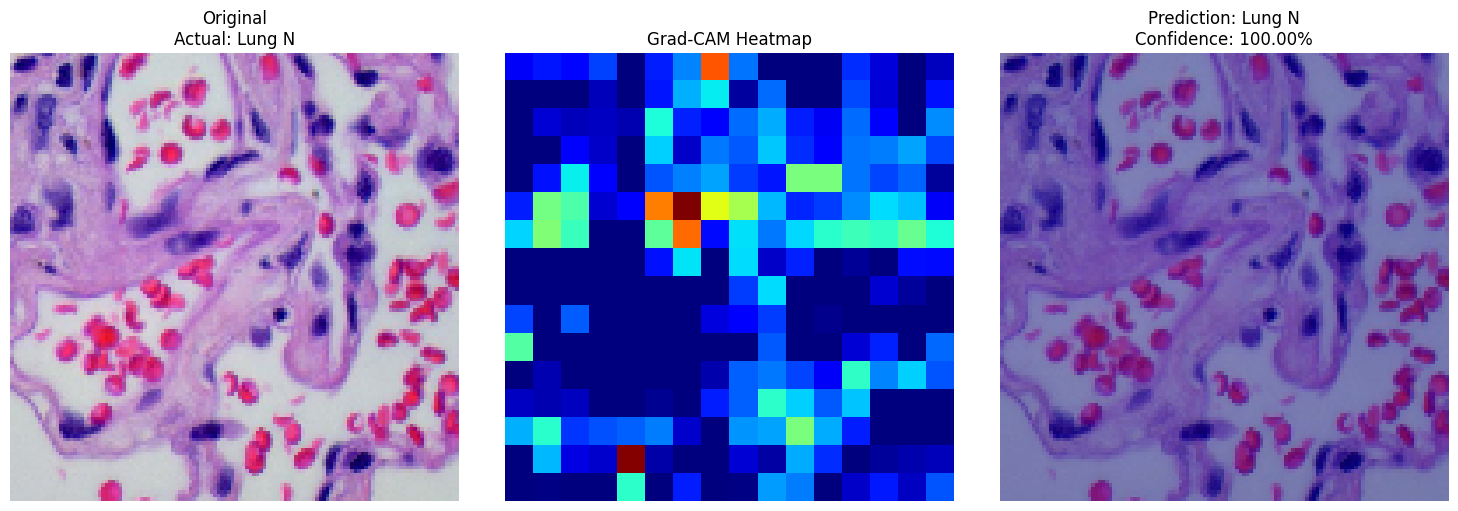

In [17]:
# Try Grad-CAM on one image

sample_row = test_df.sample(
    1,
    random_state=SEED,
).iloc[0]

original = tf.keras.utils.load_img(
    sample_row["path"],
    target_size=IMG_SIZE,
)

original_array = tf.keras.utils.img_to_array(
    original
)

input_array = (
    original_array.astype("float32")
    / 255.0
)

# Ensure the model is fully called and built on the inputs
_ = model(input_array[None, ...])

probabilities = model.predict(
    input_array[None, ...],
    verbose=0,
)[0]

predicted_id = int(
    np.argmax(probabilities)
)

# Redefining a robust Grad-CAM helper locally to bypass Keras 3 Sequential output tracing limitations
def make_gradcam_heatmap_fixed(
    image_batch,
    model,
    last_conv_layer_name,
    pred_index=None,
):
    # Re-build a functional model from the sequential layers to guarantee clean symbolic outputs
    img_input = tf.keras.Input(shape=(*IMG_SIZE, 3))
    x = img_input
    conv_out = None

    for layer in model.layers:
        x = layer(x)
        if layer.name == last_conv_layer_name:
            conv_out = x

    grad_model = tf.keras.models.Model(img_input, [conv_out, x])

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(image_batch)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_score = predictions[:, pred_index]

    gradients = tape.gradient(class_score, conv_outputs)
    pooled_gradients = tf.reduce_mean(gradients, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_gradients[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)
    heatmap /= (tf.reduce_max(heatmap) + tf.keras.backend.epsilon())
    return heatmap.numpy()

heatmap = make_gradcam_heatmap_fixed(
    input_array[None, ...],
    model,
    "gradcam_conv",
    predicted_id,
)

overlay = overlay_gradcam(
    original_array,
    heatmap,
)

actual_name = (
    sample_row["label"]
    .replace("_", " ")
    .title()
)

predicted_name = (
    CLASS_NAMES[predicted_id]
    .replace("_", " ")
    .title()
)

confidence = float(
    probabilities[predicted_id]
)

fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5),
)

axes[0].imshow(
    np.uint8(original_array)
)
axes[0].set_title(
    f"Original\nActual: {actual_name}"
)

axes[1].imshow(
    heatmap,
    cmap="jet",
)
axes[1].set_title(
    "Grad-CAM Heatmap"
)

axes[2].imshow(
    overlay
)
axes[2].set_title(
    f"Prediction: {predicted_name}\n"
    f"Confidence: {confidence:.2%}"
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [18]:
# Find the last convolutional layer automatically

conv_layers = [
    layer for layer in model.layers
    if isinstance(layer, tf.keras.layers.Conv2D)
]

last_conv_layer_name = conv_layers[-1].name

print("Grad-CAM will use:", last_conv_layer_name)


Grad-CAM will use: gradcam_conv


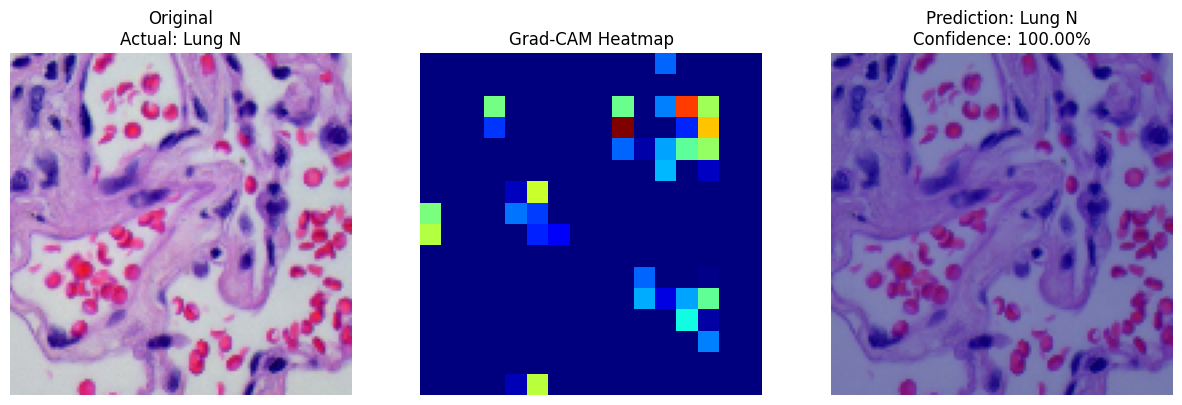

In [19]:
# Grad-CAM for one test image

sample_row = test_df.sample(1, random_state=SEED).iloc[0]

original = tf.keras.utils.load_img(
    sample_row["path"],
    target_size=IMG_SIZE
)

original_array = tf.keras.utils.img_to_array(original)

input_array = original_array.astype("float32") / 255.0

probabilities = model.predict(
    input_array[None, ...],
    verbose=0
)[0]

predicted_id = int(np.argmax(probabilities))

heatmap = make_gradcam_heatmap_fixed(
    input_array[None, ...],
    model,
    last_conv_layer_name,
    predicted_id
)

overlay = overlay_gradcam(
    original_array,
    heatmap
)

actual_name = (
    sample_row["label"]
    .replace("_", " ")
    .title()
)

predicted_name = (
    CLASS_NAMES[predicted_id]
    .replace("_", " ")
    .title()
)

confidence = float(probabilities[predicted_id])

fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5)
)

axes[0].imshow(np.uint8(original_array))
axes[0].set_title(f"Original\nActual: {actual_name}")

axes[1].imshow(heatmap, cmap="jet")
axes[1].set_title("Grad-CAM Heatmap")

axes[2].imshow(overlay)
axes[2].set_title(
    f"Prediction: {predicted_name}\n"
    f"Confidence: {confidence:.2%}"
)

for ax in axes:
    ax.axis("off")

plt.show()

## 17. Conclusion

This project developed a Convolutional Neural Network (CNN) for the
classification of lung and colon tissue images.

The model was evaluated using accuracy, precision, recall, F1-score, and
a confusion matrix to understand its classification performance. Grad-CAM
was also used to visualize the image regions that contributed to the
model's predictions.

The results demonstrate how deep learning and explainable AI techniques
can be combined for image classification and model interpretation.

 **Note:** This project is intended for educational and research purposes
 only and should not be used as a medical diagnostic system.